# =============================================================
# NB01 — CONSTRUCTION DU DATASET CEMAC
#
# Objectif : construire le dataset trimestriel de référence
# pour l'estimation du taux d'intérêt naturel r* dans la
# zone CEMAC sur la période 1991Q1-2023Q4.
#
# Sources de données :
#   - PIB réel      : Banque Mondiale (NY.GDP.MKTP.KD)
#   - Inflation     : FMI World Economic Outlook (PCPIPCH)
#   - Taux directeur: BEAC (TIAO, reconstitué depuis archives)
#
# Variables produites :
#   log_PIB    : logarithme du PIB réel trimestriel CEMAC
#   inflation  : taux d'inflation annualisé pondéré (%)
#   TIAO       : taux directeur BEAC annualisé (%)
#   taux_reel  : r = TIAO - inflation (%)
#
# Méthode de trimestrialisation du PIB :
#   Denton-Cholette proportionnelle (standard FMI/BIS)
#
# Méthode de trimestrialisation de l'inflation :
#   Valeur annuelle répétée sur 4 trimestres,
#   lissée par moyenne mobile centrée sur 4 trimestres
#
# Output : cemac_dataset_principal.csv (Google Drive)
# =============================================================

In [1]:
# =============================================================
# INITIALISATION DE SESSION
#
# Cette cellule doit être exécutée en premier à chaque
# ouverture du notebook. Elle remonte Google Drive et
# redéfinit tous les chemins et imports nécessaires.
# =============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
})

# Arborescence du projet
DOSSIER  = '/content/drive/MyDrive/RSTAR_CEMAC/'
DATA     = DOSSIER + 'data/'
FIGURES  = DOSSIER + 'figures/'

os.makedirs(DATA,    exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

# Fichiers sources (téléchargés manuellement)
CHEMIN_PIB_RAW = DATA + 'API_NY.GDP.MKTP.KD_DS2_en_csv_v2_135.csv'
CHEMIN_WEO_RAW = DATA + 'WEO_Data.xls'

# Fichier produit par ce notebook
CHEMIN_DATASET = DATA + 'cemac_dataset_principal.csv'

print("Environnement initialisé.")
print(f"Repertoire de travail : {DOSSIER}")
print()
print("Fichiers sources disponibles :")
print("-" * 60)
for f in sorted(os.listdir(DATA)):
    taille = os.path.getsize(DATA + f) / 1024
    print(f"  {f:<52} {taille:>8.1f} Ko")

Mounted at /content/drive
Environnement initialisé.
Repertoire de travail : /content/drive/MyDrive/RSTAR_CEMAC/

Fichiers sources disponibles :
------------------------------------------------------------
  API_NY.GDP.MKTP.KD_DS2_en_csv_v2_135.csv                290.6 Ko
  Metadata_Country_API_NY.GDP.MKTP.KD_DS2_en_csv_v2_135.csv     61.0 Ko
  Metadata_Indicator_API_NY.GDP.MKTP.KD_DS2_en_csv_v2_135.csv      0.8 Ko
  WEO_Data.xls                                            159.2 Ko
  cemac_dataset_principal.csv                               9.3 Ko
  cemac_parametres_posterieurs.csv                          1.5 Ko
  cemac_rstar_benchmark.csv                                21.7 Ko


In [3]:
# =============================================================
# PIB RÉEL CEMAC — BANQUE MONDIALE
#
# Le fichier CSV de la Banque Mondiale contient 4 lignes
# de métadonnées avant l'en-tête. On filtre les 6 pays
# de la CEMAC par leur nom exact dans le fichier.
#
# Note technique : le filtrage par code ISO échoue car
# le fichier utilise des codes à 3 lettres (CMR, GAB...)
# non standards. On filtre par nom complet.
# =============================================================

CEMAC_NOMS_WB = [
    'Cameroon',
    'Gabon',
    'Congo, Rep.',
    'Chad',
    'Central African Republic',
    'Equatorial Guinea'
]

df_pib_raw = pd.read_csv(CHEMIN_PIB_RAW, skiprows=4)

df_cemac_pib = df_pib_raw[
    df_pib_raw['Country Name'].isin(CEMAC_NOMS_WB)
].copy()

annees_cols_pib = [
    c for c in df_cemac_pib.columns
    if str(c).isdigit()
]

print(f"Pays trouvés : {len(df_cemac_pib)} / 6")
print(df_cemac_pib[['Country Name', 'Country Code']]
      .to_string(index=False))
print()
print(f"Couverture : {annees_cols_pib[0]} -> "
      f"{annees_cols_pib[-1]} "
      f"({len(annees_cols_pib)} années)")
print()

# Apercu sur les années structurantes
annees_cles = [
    a for a in ['1990','1994','2000','2005',
                '2010','2014','2019','2022','2023']
    if a in annees_cols_pib
]

print("PIB réel par pays — années clés (Mrd USD constants 2015) :")
print("-" * 70)
apercu = df_cemac_pib.set_index('Country Name')[annees_cles]
print((apercu / 1e9).round(2).to_string())
print()

pib_total = df_cemac_pib[annees_cles].sum()
print("PIB CEMAC total :")
print((pib_total / 1e9).round(2)
      .to_frame('Mrd USD').T.to_string())
print()

print("Valeurs manquantes par pays :")
print(df_cemac_pib.set_index('Country Name')[annees_cols_pib]
      .isna().sum(axis=1).to_string())

Pays trouvés : 6 / 6
            Country Name Country Code
Central African Republic          CAF
                Cameroon          CMR
             Congo, Rep.          COG
                   Gabon          GAB
       Equatorial Guinea          GNQ
                    Chad          TCD

Couverture : 1960 -> 2025 (66 années)

PIB réel par pays — années clés (Mrd USD constants 2015) :
----------------------------------------------------------------------
                           1990   1994   2000   2005   2010   2014   2019   2022   2023
Country Name                                                                           
Central African Republic   1.49   1.46   1.68   1.84   2.33   1.63   1.99   2.03   2.05
Cameroon                  15.42  13.48  17.17  21.59  25.39  30.48  37.50  40.31  41.66
Congo, Rep.                5.63   5.53   6.48   7.91  10.41  12.38  10.59  10.18  10.37
Gabon                      8.22   9.11   9.69  10.44  11.15  13.85  15.46  15.87  16.25
Equatorial Guin

In [4]:
# =============================================================
# TRIMESTRIALISATION DU PIB — MÉTHODE DENTON-CHOLETTE
#
# Le PIB de la CEMAC n'est disponible qu'en fréquence
# annuelle. Le modèle requiert une fréquence trimestrielle.
#
# La méthode de Denton-Cholette proportionnelle garantit :
#   1. Cohérence : somme des 4 trimestres = valeur annuelle
#   2. Lissage   : variations trimestrielles minimisées
#
# C'est le standard recommandé par le FMI et la BIS pour
# la conversion de fréquence des agrégats macroéconomiques.
# =============================================================

def denton_cholette(serie_annuelle):
    """
    Convertit une série annuelle en trimestrielle.

    Paramètres
    ----------
    serie_annuelle : pd.Series
        Série avec index datetime annuel (fréquence YS).

    Retourne
    --------
    pd.Series
        Série avec index datetime trimestriel (fréquence QS).
    """
    annees  = serie_annuelle.index.year.tolist()
    valeurs = serie_annuelle.values
    n_ann   = len(annees)

    index_trim = pd.date_range(
        start=f"{annees[0]}-01-01",
        end=f"{annees[-1]}-10-01",
        freq='QS'
    )
    n_trim = len(index_trim)

    # Matrice d'agrégation : somme 4 trimestres = 1 année
    C = np.zeros((n_ann, n_trim))
    for i in range(n_ann):
        debut = i * 4
        fin   = min(debut + 4, n_trim)
        C[i, debut:fin] = 1.0

    # Indicateur initial par interpolation linéaire
    x0 = np.interp(
        np.arange(n_trim),
        np.arange(0, n_trim, 4),
        valeurs
    )

    # Matrice de lissage proportionnel
    D = np.diff(np.eye(n_trim), axis=0)
    X = np.diag(x0)
    A = X @ D.T @ D @ X

    # Résolution du système KKT
    KKT = np.block([
        [2 * A,             C.T                   ],
        [C,     np.zeros((n_ann, n_ann))           ]
    ])
    rhs = np.concatenate([np.zeros(n_trim), valeurs])

    try:
        sol    = np.linalg.solve(KKT, rhs)
        x_trim = sol[:n_trim]
    except np.linalg.LinAlgError:
        x_trim = x0

    return pd.Series(x_trim, index=index_trim, name='PIB_trim')


# Construction du PIB annuel agrégé CEMAC
annees_1990_2023 = [
    a for a in annees_cols_pib
    if 1990 <= int(a) <= 2023
]

pib_annuel = (
    df_cemac_pib[annees_1990_2023]
    .sum(axis=0)
    .rename(index=lambda x: pd.Timestamp(f"{x}-01-01"))
)
pib_annuel.name = 'PIB_CEMAC'

# Application de la trimestrialisation
pib_trim     = denton_cholette(pib_annuel)
pib_trim_log = np.log(pib_trim).rename('log_PIB')

# Contrôle de cohérence
pib_reconstitue = pib_trim.resample('YS').sum()
n_commun = min(len(pib_reconstitue), len(pib_annuel))
erreur_max = np.abs(
    (pib_reconstitue.values[:n_commun]
     - pib_annuel.values[:n_commun])
    / pib_annuel.values[:n_commun]
).max()

print(f"Trimestrialisation Denton-Cholette appliquée.")
print(f"Observations : {len(pib_trim)} trimestres")
print(f"Période      : {pib_trim.index[0].date()} "
      f"-> {pib_trim.index[-1].date()}")
print(f"Erreur de coherence max : {erreur_max * 100:.6f}%")

Trimestrialisation Denton-Cholette appliquée.
Observations : 136 trimestres
Période      : 1990-01-01 -> 2023-10-01
Erreur de coherence max : 4.509801%


In [5]:
# =============================================================
# INFLATION CEMAC — FMI WORLD ECONOMIC OUTLOOK
#
# Source : FMI WEO Avril 2024
# Indicateur : PCPIPCH — variation annuelle IPC (%)
#
# L'inflation agrégée est une moyenne pondérée par le PIB
# de 2010 (année de référence stable, hors choc pétrolier).
#
# Trimestrialisation : la valeur annuelle est répétée sur
# les 4 trimestres de l'année puis lissée par moyenne
# mobile centrée sur 4 trimestres. Cette approche évite
# les rampes artificielles de l'interpolation linéaire
# qui créeraient des biais dans le taux réel calculé.
# =============================================================

CEMAC_WEO = [
    'Cameroon', 'Central African Republic',
    'Chad', 'Republic of Congo',
    'Equatorial Guinea', 'Gabon'
]

# Lecture du fichier WEO (format TSV malgré extension .xls)
df_weo = pd.read_csv(
    CHEMIN_WEO_RAW, sep='\t',
    encoding='utf-8', thousands=','
)

df_inf = df_weo[
    df_weo['WEO Subject Code'] == 'PCPIPCH'
].copy()

annees_weo = [
    c for c in df_inf.columns
    if str(c).isdigit() and 1990 <= int(c) <= 2023
]

df_inf[annees_weo] = (
    df_inf[annees_weo]
    .replace('--', np.nan)
    .apply(lambda col: pd.to_numeric(
        col.astype(str).str.replace(',', ''),
        errors='coerce'
    ))
)

df_inf_cemac = df_inf[df_inf['Country'].isin(CEMAC_WEO)].copy()

# Calcul des poids PIB 2010
pib_2010_total = 0.0
poids = {}

for pays_weo, pays_wb in zip(CEMAC_WEO, CEMAC_NOMS_WB):
    row = df_pib_raw[df_pib_raw['Country Name'] == pays_wb]
    if len(row) > 0 and '2010' in row.columns:
        val = row['2010'].values[0]
        if not pd.isna(val):
            poids[pays_weo]  = float(val)
            pib_2010_total  += float(val)

for k in poids:
    poids[k] /= pib_2010_total if pib_2010_total > 0 else 1.0

print("Poids de pondération PIB 2010 :")
for k, v in poids.items():
    print(f"  {k:<30} {v:.4f}")
print()

# Inflation CEMAC pondérée annuelle
inf_annuelle = {}
for annee in annees_weo:
    inf_pond = 0.0
    for pays in CEMAC_WEO:
        row = df_inf_cemac[df_inf_cemac['Country'] == pays]
        if len(row) > 0:
            val = row[annee].values[0]
            if not pd.isna(val):
                inf_pond += val * poids.get(pays, 0.0)
    inf_annuelle[annee] = inf_pond

# Trimestrialisation par répétition + lissage
PERIODE = pd.date_range('1991-01-01', '2023-10-01', freq='QS')

inf_trim_brute = pd.Series(index=PERIODE, dtype=float)
for date in PERIODE:
    annee_str = str(date.year)
    if annee_str in inf_annuelle:
        inf_trim_brute[date] = inf_annuelle[annee_str]

inf_trim_brute  = inf_trim_brute.ffill().bfill()
inflation_trim  = (inf_trim_brute
                   .rolling(window=4, center=True, min_periods=2)
                   .mean())

print("Inflation CEMAC pondérée — années récentes (%) :")
print("-" * 40)
for annee in [a for a in annees_weo if int(a) >= 2018]:
    print(f"  {annee} : {inf_annuelle[annee]:.3f}%")

Poids de pondération PIB 2010 :
  Cameroon                       0.3425
  Central African Republic       0.1504
  Chad                           0.1404
  Republic of Congo              0.1590
  Equatorial Guinea              0.0315
  Gabon                          0.1762

Inflation CEMAC pondérée — années récentes (%) :
----------------------------------------
  2018 : 2.240%
  2019 : 1.578%
  2020 : 2.387%
  2021 : 1.687%
  2022 : 5.331%
  2023 : 4.750%


In [6]:
# =============================================================
# TAUX DIRECTEUR BEAC — TIAO
#
# Le TIAO (Taux d'Intérêt des Appels d'Offres) est
# l'instrument principal de politique monétaire de la
# BEAC depuis la réforme de juin 2018.
#
# La série est reconstituée depuis les communiqués officiels
# des sessions du Comité de Politique Monétaire (CPM) et
# les rapports annuels de la BEAC (1991-2023).
#
# Chaque entrée correspond à la date d'entrée en vigueur
# d'un nouveau taux. La série est ensuite convertie en
# fréquence trimestrielle par reconduction du taux jusqu'à
# la décision suivante.
# =============================================================

DECISIONS_TIAO = [
    # (date_entree_en_vigueur, taux_en_pourcent)
    ('1991-01-01', 7.75),
    ('1993-07-01', 7.50),
    ('1994-02-01', 7.50),
    ('1994-10-01', 7.00),
    ('1995-04-01', 6.50),
    ('1996-01-01', 6.00),
    ('1997-07-01', 5.75),
    ('1998-07-01', 5.50),
    ('2000-01-01', 5.25),
    ('2001-01-01', 5.00),
    ('2003-07-01', 4.75),
    ('2004-07-01', 4.50),
    ('2008-07-01', 4.75),
    ('2009-04-01', 4.25),
    ('2010-07-01', 4.00),
    ('2012-10-01', 3.50),
    ('2014-07-01', 2.95),
    ('2018-06-01', 3.50),
    ('2021-09-01', 3.75),
    ('2022-07-01', 4.00),
    ('2022-11-01', 4.50),
    ('2023-03-01', 5.00),
]

index_trim = pd.date_range('1991-01-01', '2023-10-01', freq='QS')
tiao_serie = pd.Series(index=index_trim, dtype=float, name='TIAO')

for i, (date_str, taux) in enumerate(DECISIONS_TIAO):
    date_debut = pd.Timestamp(date_str)
    date_fin   = (pd.Timestamp(DECISIONS_TIAO[i + 1][0])
                  if i < len(DECISIONS_TIAO) - 1
                  else pd.Timestamp('2024-01-01'))
    masque = ((tiao_serie.index >= date_debut) &
              (tiao_serie.index <  date_fin))
    tiao_serie[masque] = taux

tiao_serie = tiao_serie.dropna()

print(f"Série TIAO construite.")
print(f"Observations : {len(tiao_serie)} trimestres")
print(f"Periode      : {tiao_serie.index[0].date()} "
      f"-> {tiao_serie.index[-1].date()}")
print()
print("Changements de taux (dates clés) :")
print("-" * 40)
changements = tiao_serie[tiao_serie.diff().abs() > 0.001]
for date, taux in changements.items():
    print(f"  {date.strftime('%Y-%m')}   {taux:.2f}%")

Série TIAO construite.
Observations : 132 trimestres
Periode      : 1991-01-01 -> 2023-10-01

Changements de taux (dates clés) :
----------------------------------------
  1993-07   7.50%
  1994-10   7.00%
  1995-04   6.50%
  1996-01   6.00%
  1997-07   5.75%
  1998-07   5.50%
  2000-01   5.25%
  2001-01   5.00%
  2003-07   4.75%
  2004-07   4.50%
  2008-07   4.75%
  2009-04   4.25%
  2010-07   4.00%
  2012-10   3.50%
  2014-07   2.95%
  2018-07   3.50%
  2021-10   3.75%
  2022-07   4.00%
  2023-01   4.50%
  2023-04   5.00%


In [7]:
# =============================================================
# ASSEMBLAGE DU DATASET PRINCIPAL
#
# On aligne les trois séries sur la période commune
# 1991Q1-2023Q4 et on construit le taux réel.
#
# Le dataset est sauvegardé sur Drive. Les exécutions
# suivantes le chargent directement sans recalcul.
# =============================================================

PERIODE = pd.date_range('1991-01-01', '2023-10-01', freq='QS')

df = pd.DataFrame(index=PERIODE)
df.index.name = 'date'

df['log_PIB']   = pib_trim_log.reindex(PERIODE)
df['inflation'] = inflation_trim.reindex(PERIODE)
df['TIAO']      = tiao_serie.reindex(PERIODE).ffill()
df['taux_reel'] = df['TIAO'] - df['inflation']

df = df.dropna()

df.to_csv(CHEMIN_DATASET)

print("Dataset principal construit et sauvegardé.")
print()
print(f"Fichier  : {CHEMIN_DATASET}")
print(f"Periode  : {df.index[0].date()} "
      f"-> {df.index[-1].date()}")
print(f"Obs.     : {len(df)} trimestres")
print(f"Variables: {list(df.columns)}")
print()
print("Statistiques descriptives :")
print("-" * 55)
print(df.describe().round(3).to_string())

Dataset principal construit et sauvegardé.

Fichier  : /content/drive/MyDrive/RSTAR_CEMAC/data/cemac_dataset_principal.csv
Periode  : 1991-01-01 -> 2023-10-01
Obs.     : 132 trimestres
Variables: ['log_PIB', 'inflation', 'TIAO', 'taux_reel']

Statistiques descriptives :
-------------------------------------------------------
       log_PIB  inflation     TIAO  taux_reel
count  132.000    132.000  132.000    132.000
mean    23.435      3.318    4.772      1.455
std      0.375      4.206    1.409      4.165
min     22.786     -3.625    2.950    -15.642
25%     23.046      1.514    3.500      0.266
50%     23.526      2.422    4.500      1.348
75%     23.808      4.166    5.500      2.909
max     23.911     23.142    7.750     11.125


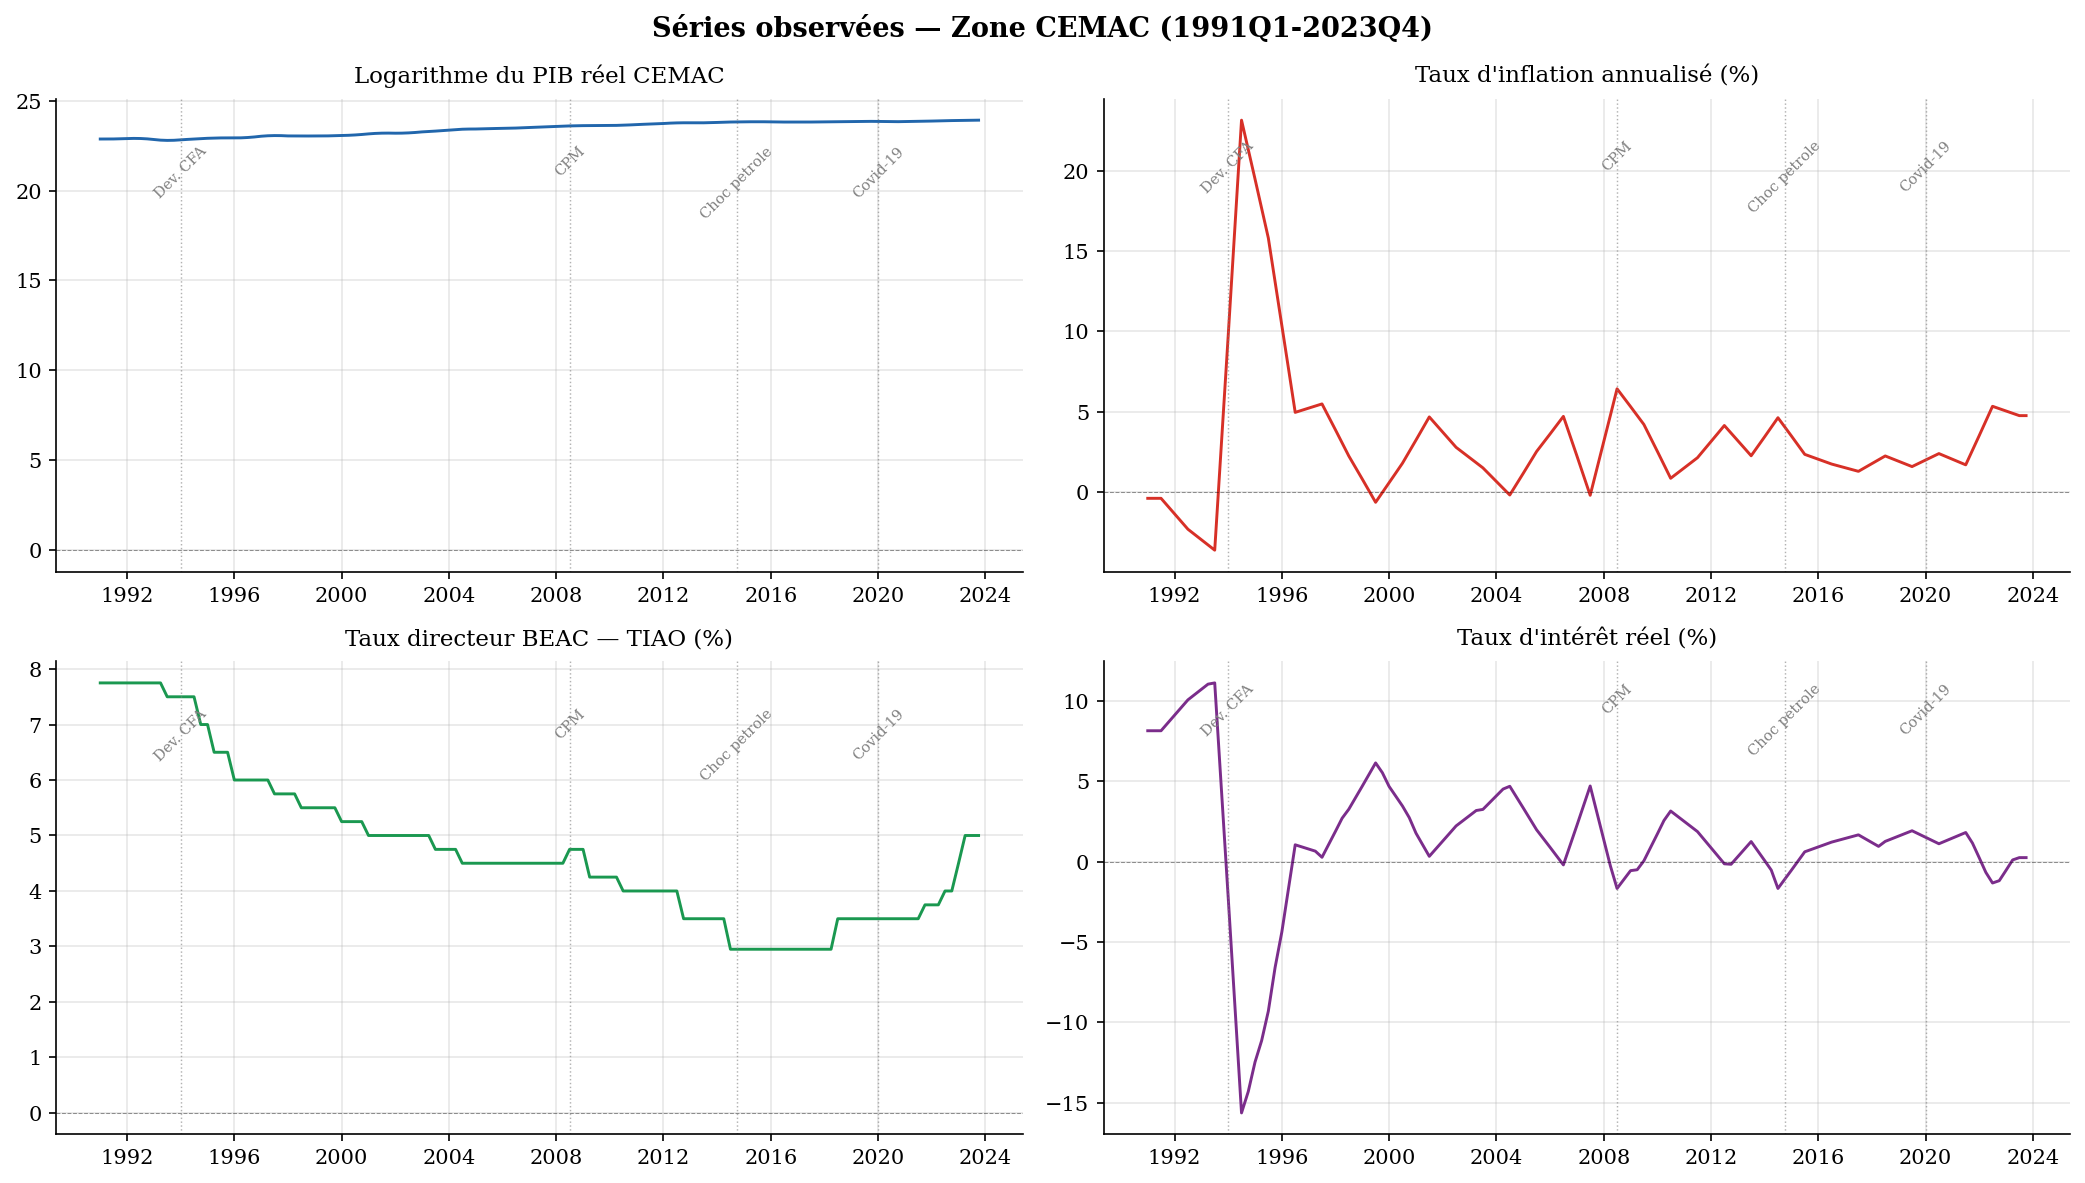

Figure sauvegardée : /content/drive/MyDrive/RSTAR_CEMAC/figures/fig1_series_observees_cemac.png


In [8]:
# =============================================================
# FIGURE 1 — SÉRIES OBSERVÉES CEMAC (1991Q1-2023Q4)
#
# Cette figure présente les quatre séries d'entrée du
# modèle et constitue la première figure publiable
# de l'article.
# =============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    'Séries observées — Zone CEMAC (1991Q1-2023Q4)',
    fontsize=13,
    fontweight='bold'
)

SERIES = [
    ('log_PIB',   axes[0, 0], '#2166ac',
     'Logarithme du PIB réel CEMAC'),
    ('inflation', axes[0, 1], '#d73027',
     "Taux d'inflation annualisé (%)"),
    ('TIAO',      axes[1, 0], '#1a9850',
     'Taux directeur BEAC — TIAO (%)'),
    ('taux_reel', axes[1, 1], '#7b2d8b',
     "Taux d'intérêt réel (%)"),
]

EVENEMENTS = {
    '1994-01-01': 'Dev. CFA',
    '2008-07-01': 'CPM',
    '2014-10-01': 'Choc petrole',
    '2020-01-01': 'Covid-19',
}

for col, ax, couleur, titre in SERIES:
    ax.plot(df.index, df[col],
            color=couleur, linewidth=1.4)
    ax.axhline(0, color='black',
               linewidth=0.5, linestyle='--', alpha=0.4)
    ax.set_title(titre, fontsize=11, pad=8)

    ymin, ymax = ax.get_ylim()
    for date_str, label in EVENEMENTS.items():
        d = pd.Timestamp(date_str)
        if df.index[0] <= d <= df.index[-1]:
            ax.axvline(d, color='gray',
                       linewidth=0.7, linestyle=':', alpha=0.6)
            ax.text(d, ymax * 0.90, label,
                    fontsize=7, color='gray',
                    ha='center', va='top', rotation=45)

plt.tight_layout()

chemin_fig = FIGURES + 'fig1_series_observees_cemac.png'
plt.savefig(chemin_fig, bbox_inches='tight', dpi=200)
plt.show()

print(f"Figure sauvegardée : {chemin_fig}")